## 1. Import necessary Libraries

In [8]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 2. Load the dataset

In [9]:
california_housing_data=fetch_california_housing()

In [11]:
california_housing_df=pd.DataFrame(data=california_housing_data.data,columns=california_housing_data.feature_names)
california_housing_df["Target"]=california_housing_data.target
california_housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## 3. Data Understanding

In [12]:
california_housing_df.shape

(20640, 9)

In [13]:
california_housing_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

In [14]:
california_housing_df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Target        float64
dtype: object

## 4. Data Preprocessing/ Preparation

In [15]:
# There is no null values or the object and hence there is no need to perform any imputation or the conversion from object to numeric datatype.

In [23]:
X=california_housing_df.drop(labels="Target",axis=1)
y=california_housing_df["Target"]

In [20]:
#X=X.head(350)
#y=y[:350]

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,shuffle=True,random_state=42)

## 5. Model Building

In [26]:
linear_model=LinearRegression()
lasso_model=Lasso(alpha=1.0)
ridge_model=Ridge(alpha=1.0)
elasticnet_model=ElasticNet(alpha=1.0)

## 6. Model Training

In [43]:
linear_model.fit(X_train,y_train)
lasso_model.fit(X_train,y_train)
ridge_model.fit(X_train,y_train)
elasticnet_model.fit(X_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [ ]:
# print coefficients

In [44]:
print("Linear Model Coefficients:\n",linear_model.coef_)
print("Lasso Coefficients:\n",lasso_model.coef_)
print("Ridge Coefficients:\n",ridge_model.coef_)
print("ElasticNet Coefficients:\n",elasticnet_model.coef_)

Linear Model Coefficients:
 [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Lasso Coefficients:
 [ 1.48196324e-01  5.72821070e-03  0.00000000e+00 -0.00000000e+00
 -8.16437293e-06 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
Ridge Coefficients:
 [ 4.48510924e-01  9.72596535e-03 -1.23014157e-01  7.81416761e-01
 -2.02581346e-06 -3.52585878e-03 -4.19786908e-01 -4.33680793e-01]
ElasticNet Coefficients:
 [ 2.55274615e-01  1.12300735e-02  0.00000000e+00 -0.00000000e+00
  7.75939261e-06 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]


In [38]:
import matplotlib.pyplot as plt

# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    coef_df=pd.DataFrame({ "Feature": feature_names,
                            "Coefficient": model.coef_
                        })
    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()

      Feature  Coefficient
7   Longitude    -0.433708
6    Latitude    -0.419792
2    AveRooms    -0.123323
5    AveOccup    -0.003526
4  Population    -0.000002
1    HouseAge     0.009724
0      MedInc     0.448675
3   AveBedrms     0.783145


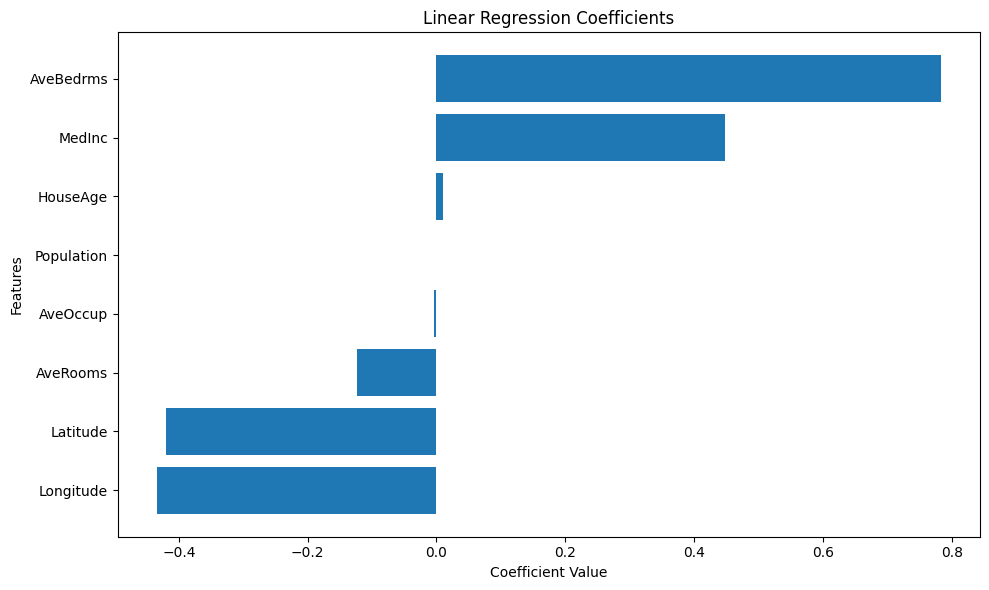

      Feature  Coefficient
7   Longitude    -0.433681
6    Latitude    -0.419787
2    AveRooms    -0.123014
5    AveOccup    -0.003526
4  Population    -0.000002
1    HouseAge     0.009726
0      MedInc     0.448511
3   AveBedrms     0.781417


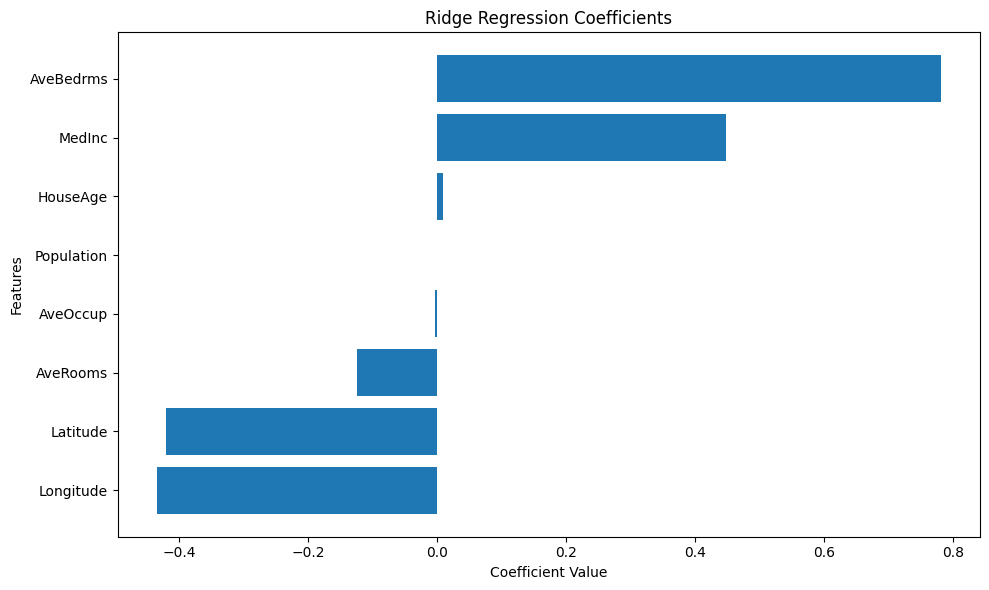

      Feature  Coefficient
4  Population    -0.000008
3   AveBedrms    -0.000000
5    AveOccup    -0.000000
2    AveRooms     0.000000
6    Latitude    -0.000000
7   Longitude    -0.000000
1    HouseAge     0.005728
0      MedInc     0.148196


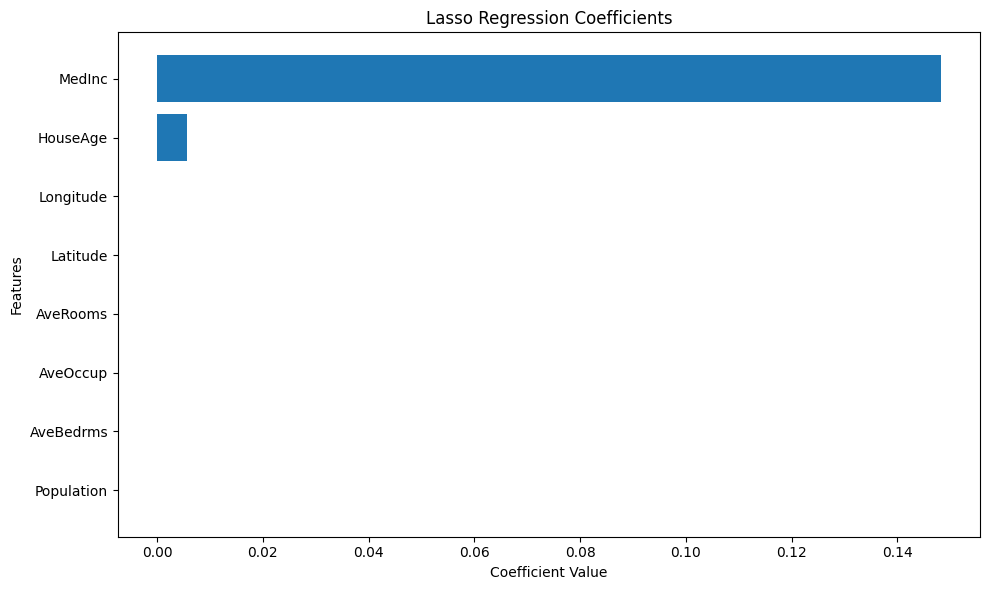

      Feature  Coefficient
3   AveBedrms    -0.000000
2    AveRooms     0.000000
6    Latitude    -0.000000
5    AveOccup    -0.000000
7   Longitude    -0.000000
4  Population     0.000008
1    HouseAge     0.011230
0      MedInc     0.255275


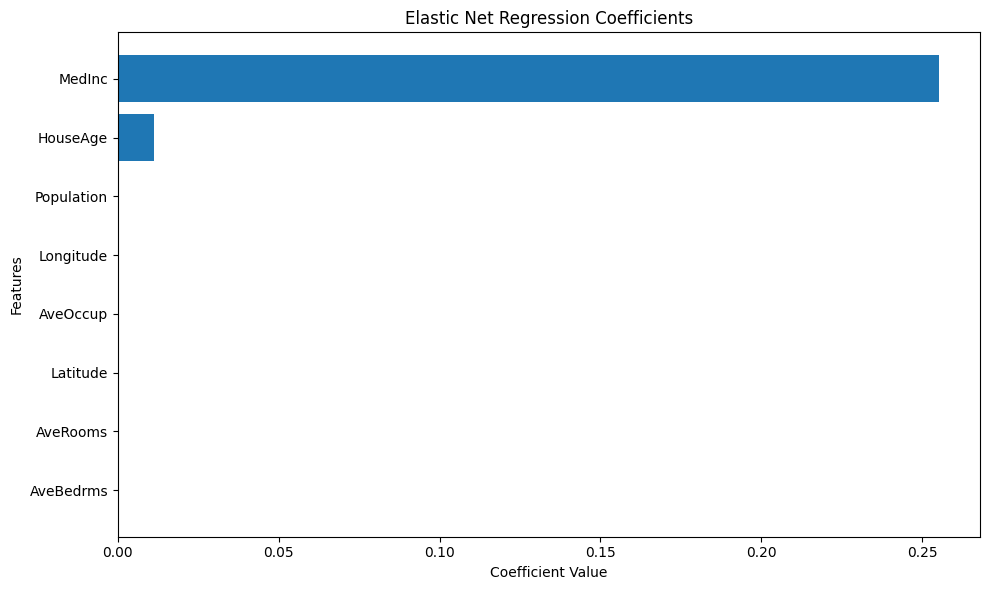

In [40]:
# Linear Regression
plot_coefficients(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)

# Ridge Regression
plot_coefficients(
    ridge_model,
    X.columns,
    "Ridge Regression Coefficients"
)

# Lasso Regression
plot_coefficients(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)

# Elastic Net
plot_coefficients(
    elasticnet_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)

In [42]:
models = {
    "Linear": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elasticnet_model
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(name)
    print("MSE:", mse)
    print("R2:", r2)
    print()

Linear
MSE: 0.555891598695244
R2: 0.5757877060324511

Ridge
MSE: 0.5558034669932209
R2: 0.5758549611440127

Lasso
MSE: 0.9380337514945429
R2: 0.28416718210083947

ElasticNet
MSE: 0.7645556403971132
R2: 0.41655189098028234

